# Oxygen Evolution Reaction (OER) Catalyst Screening with NVIDIA ALCHEMI NIMs

<div style="display: flex; align-items: center; justify-content: flex-start; gap: 0; margin-top: 10px;">
  <img src="assets/eneos_logo.png" style="height: 40px;">
  <div style="width: 1px; height: 35px; background: #999; margin: 0 20px;"></div>
  <img src="assets/matlantis_logo.png" style="height: 25px;">
  <div style="width: 1px; height: 35px; background: #999; margin: 0 20px;"></div>
  <img src="assets/nvidia-logo.png" style="height: 45px;">
</div>

## Motivation

### The Hydrogen Opportunity

Hydrogen is a clean-burning fuel that produces only water when consumed. If it can be manufactured cheaply from water and renewable electricity, it becomes a cornerstone of the energy transition — powering heavy transport, steel-making, and chemical synthesis without carbon emissions. The simplest route is **water electrolysis**: pass an electric current through water and it splits into hydrogen gas (H$_2$) at the cathode and oxygen gas (O$_2$) at the anode. In principle, the minimum voltage required is just **1.23 V**. In practice, today's electrolysers need substantially more — the extra voltage, called the **overpotential**, is wasted as heat. Most of that penalty comes from the oxygen side of the reaction, known as the **Oxygen Evolution Reaction (OER)**.

### The Catalyst Bottleneck

A good OER catalyst lowers the overpotential, making the process more energy-efficient. Currently, the best-performing and most widely-used catalyst for acidic electrolysers is **iridium oxide (IrO$_2$)**, but iridium is one of the rarest elements on Earth, with global iridium production is hovering around 7–8 tonnes per year. The **U.S. Geological Survey lists it among its 60 critical minerals** — materials vital to the economy whose supply chains are vulnerable to disruption. There is therefore urgent industrial interest in finding cheaper, more abundant alternatives.

### Computational Screening

Testing catalyst candidates in the laboratory is expensive and slow. **Computational screening** lets researchers evaluate hundreds of candidate structures on a _in silico_ *before* committing to experiments. By simulating how oxygen-containing molecules bind to a catalyst surface, we can rank materials by their predicted activity and expense our laboratory work only on the most promising candidates.

This playbook demonstrates one such workflow to accomplish this using the **NVIDIA ALCHEMI's BGR (Batched Geometry Relaxation) NIM**. In this simple demonstration, we screen three oxide catalyst surfaces — **IrO$_2$**, **RuO$_2$**, and **TiO$_2$** — for their interaction with key OER intermediates. The workflow is based off of a collaboration between **ENEOS**, **Matlantis**, and **NVIDIA**, that allowed ENEOS to evaluate close to 100 million material hypotheses and produced approximately 1,000 promising catalyst compositions for prioritized synthesis and testing. Intersted readers can learn more about NVIDIA ALCHEMI from our latest [_tech blog_](https://developer.nvidia.com/blog/faster-chemistry-and-materials-discovery-with-ai-powered-simulations-using-nvidia-alchemi/).

_“The 100+ shortlisted candidates include some well-known OER catalysts, which validates our screening strategy based on overpotential. On the other hand, it suggests surprisingly high potential candidates out of blue. They are worth trying!”_
> – OER catalyst scientist, ENEOS Holding, Inc.

## What You Will Learn

| Section | Topic | What you will do |
|---------|-------|------------------|
| **1** | Environment Setup | Import packages, configure API endpoints and control-panel parameters |
| **2** | Endpoint Connectivity | Verify the BGR NIM is reachable; inspect health and model metadata |
| **3** | The Oxygen Evolution Reaction | Review the four-step OER mechanism and thermodynamic screening framework |
| **4** | Oxide Catalyst Surfaces | Build rutile-type bulk crystals, optimise lattice parameters, and cleave (110) surface slabs |
| **5** | Clean Slab & Gas-Phase References | Relax pristine slabs and isolated adsorbate molecules to obtain reference energies |
| **6** | Adsorbate Placement | Position H$_2$O, OH, O, and OOH at catalytically active CUS sites on each slab |
| **7** | Batched Geometry Relaxation | Submit 30+ slab-adsorbate structures to the BGR NIM in one async batch |
| **8** | Relaxation Quality Control | Classify outcomes (converged, migrated, dissociated, desorbed) and visualise surface displacement |
| **9** | Adsorption Energies | Compute $\Delta E_{\mathrm{ads}}$ for each intermediate and inspect metal–adsorbate bond lengths |
| **10** | Screening Results & Material Ranking | Plot 3D adsorption-energy scatter, energy ladders, and rank materials by proximity to the ideal OER catalyst |
| | **Discussion** | Interpret results, compare to literature, and discuss limitations of the structural screening approach |
| **11** | Extensions & Scaling | Explore scaling to larger material libraries, multi-site sampling, and further refinements |

### Prerequisites

| Requirement | Description |
|-------------|---------|
| Python | $\geq$ 3.11 |
| virtual env | installed using `uv` or `conda` through `requirements.txt` |
| BGR NIM | running on `localhost` (or set `FAST_DEMO = True` for cached mode) |

### NVIDIA NIMs

**NVIDIA NIM microservices** are containerised, GPU-optimised AI inference endpoints shipped as standard Docker containers with REST APIs. They can be deployed on any NVIDIA GPU infrastructure — from a single workstation to a multi-node cloud cluster — and are the delivery vehicle for NVIDIA’s domain-specific AI models.

**ALCHEMI** (AI Lab for CHEMistry and Materials Innovation) is NVIDIA’s platform for accelerating chemistry and materials discovery through AI-powered simulation. It is organised in three layers:

| Layer | What it provides |
|-------|-----------------|
| **Toolkit-Ops** | Low-level GPU-accelerated, batched operations (neighbour lists, dispersion corrections, long-range electrostatics) |
| **Toolkit** | Ready-made simulation building blocks — geometry optimisers, MD integrators, thermostats |
| **NIM microservices** | Cloud-ready endpoints: **BMD** (Batch Molecular Dynamics), **BGR** (Batch Geometry Relaxation), etc. |

In this workshop, we use the ALCHEMI BGR NIM which accepts batched groups of atomic structures and returns their relaxed geometries. Under the hood it runs **MACE-MP-0** [Batatia et al., *NeurIPS* (2022)] as the machine-learning interatomic potential — a foundation model covering 89 elements, trained on 1.6 million Materials Project bulk-crystal structures, driven by an in-house **FIRE**-style optimiser [Bitzek et al., *Phys. Rev. Lett.* **97**, 170201 (2006)] that efficiently drives structures toward local energy minima.

### NVIDIA ALCHEMI BGR NIM

**Key benefits of the BGR NIM:**

- **Speed/Accuracy** — ~10,000× faster with near-DFT precision for structural trends and relative energetics
- **Batching** — dynamically batches heterogeneous structures in a single request, maximising GPU utilisation and throughput
- **Reproducibility** — containerised deployment ensures identical results across environments

### Data Model & API Flow

The diagram below shows how atomic structures move between the Python libraries used in this notebook and the remote BGR NIM server. We include conversion helpers to handle serialisation in each direction.

```
  ┌──────────────────────────────────────────────────────────┐
  │                       BGR NIM Server                     │
  │            MACE-MP-0 + FIRE2 geometry optimiser          │
  └─────────────────────────┬────────┬───────────────────────┘
                            │        │
                 POST /infer│        │ JSON response
                            │        │
                ┌───────────┘        └───────────┐
                │                                │
          ┌─────┴─────┐                   ┌──────┴──────┐
          │ BGRRequest│                   │  BGRReply   │
          └─────┬─────┘                   └──────┬──────┘
                │                                │
        wraps a list of                  contains a list of
                │                                │
        ┌───────┴───────┐              ┌─────────┴─────────┐
        │ BGRAtomicData │              │ OptimizationResult│
        └───────┬───────┘              └─────────┬─────────┘
                │                                │
       ase_to_atomic_data()             atomic_data_to_ase()
                │                                │
           ┌────┴────┐                     ┌─────┴─────┐
           │ase.Atoms│                     │ ase.Atoms │
           └─────────┘                     └───────────┘
        (input structure)               (relaxed structure)
```

| Class | Key fields | Role |
|-------|-----------|------|
| **`BGRAtomicData`** | `coord`, `numbers`, `cell`, `pbc`, `active_mask`, `structure_id` | One input structure (flat coordinate list, atomic numbers, periodic cell) |
| **`BGRRequest`** | `atoms` (list of `BGRAtomicData`), `opttol`, `cellopt` | Batched request — wraps multiple structures for simultaneous relaxation |
| **`OptimizationResult`** | inherits `BGRAtomicData` + `converged`, `energy`, `forces`, `num_optimization_steps` | One relaxed structure with convergence info and final energy/forces |
| **`BGRReply`** | `atoms` (list of `OptimizationResult`), `status` | Server response — one result per request |

The conversion helpers `ase_to_atomic_data()` and `atomic_data_to_ase()` are defined in `helpers/models.py` and are made available to help us convert between these data structures and easily communicate with the BGR NIM 

### Visualisation with OVITO

<img src="assets/ovito_logo.png" alt="OVITO" style="height: 50px; float: right; margin-left: 15px;">

Throughout this notebook we use **OVITO** (Open Visualization Tool) for interactive 3-D structure visualisation. OVITO is a scientific visualisation platform for atomistic simulation data, supporting molecular dynamics, Monte Carlo, and DFT output formats [Stukowski, 2010].

OVITO integrates with **NVIDIA hardware** through the **VisRTX renderer** — a hardware-accelerated ray-tracing engine built on the **NVIDIA OptiX** RT-core technology. On CUDA-capable GPUs, VisRTX provides real-time, high-fidelity rendering with global illumination and shadows, making it possible to explore large atomic structures interactively.

The interactive widgets below support mouse rotation, zoom, and pan — try clicking and dragging to explore the 3-D scenes!!!

> **Scope note!** This notebook performs structural screening — a rapid first pass that identifies plausible binding geometries and relative trends. It is not a full thermodynamic analysis and does not replace calculations with explicit solvent, entropy corrections, or electrochemical boundary conditions. Think of it as the first funnel in a multi-stage discovery pipeline.

---
## 1. Environment Setup

In [1]:
# ─── Package Versions ─────────────────────────────────────────────────────────────
import importlib.metadata

print("Package versions:")
for pkg in ["ase", "pymatgen", "pydantic", "requests", "matplotlib", "numpy", "pandas", "ovito"]:
    print(f"  {pkg}: {importlib.metadata.version(pkg)}")

Package versions:
  ase: 3.27.0
  pymatgen: 2025.10.7
  pydantic: 2.12.5
  requests: 2.32.5
  matplotlib: 3.10.8
  numpy: 2.4.2
  pandas: 3.0.1
  ovito: 3.15.0


In [2]:
import os

# ─── Control Panel ─────────────────────────────────────────────────────────────
# Flip FAST_DEMO to True to use cached responses instead of live endpoint calls.
FAST_DEMO = False

# BGR NIM endpoint (adjust port if your deployment differs)
BGR_SERVER = os.environ.get("BGR_SERVER", "http://localhost:8000")

# Catalyst surface parameters
MILLER_INDEX = (1, 1, 0)
SUPERCELL = (6, 6, 1)
MIN_SLAB_SIZE = 10.0  # Angstrom (~4-5 layers for rutile 110)
MIN_VACUUM = 15.0  # Angstrom vacuum gap above catalyst slab

# BOTTOM_FROZEN = 0.5  # Freeze bottom 50% of slab atoms
BOTTOM_FROZEN = None

# Adsorbates and placement configurations
# ADSORBATES = ["H2O", "OH", "O", "OOH"]
ADSORBATES = ["OH", "O", "OOH"]

# cus = coordinatively unsaturated site (5-fold metal, missing one apical O)
# bridge = midpoint between two adjacent cus metals along [001]
SITES = ["cus", "bridge"]

# Tilt angles in degrees (0 = upright, 30 = tilted toward bridging oxygen)
ORIENTATIONS = [0.0, 30.0]

# Adsorbate placement height above surface site (Angstrom).
# ~2.0 A approximates the equilibrium M-O bond length for these oxides.
ADSORBATE_HEIGHT = 2.0

# Force tolerance to use for slab-adsorbate relaxations (default 5.0e-3)
FORCE_TOLERANCE = 1.0e-3

# Directories
CACHE_DIR = "cached_responses/oer-catalyst-screening"
OUTPUT_DIR = "outputs"

# Vacuum box size for gas-phase reference molecules (Angstrom)
GAS_BOX_SIZE = 30.0

# ─── Data Files ────────────────────────────────────────────────────────────────
# The following JSON files in data/ are loaded in the next cell and used
# throughout the notebook.
#
# data/rutile_params.json
#   Rutile oxide lattice parameters for each catalyst material.
#   Structure: {"IrO2": {"metal": "Ir", "a": 4.499, "c": 3.154, "u": 0.3065}, ...}
#   Keys: metal (element symbol), a/c (tetragonal cell edges in Angstrom),
#         u (oxygen Wyckoff 4f coordinate).
#   Ref: Bolzan et al., Acta Cryst. B 53, 373 (1997).
#
# data/atomic_numbers.json
#   Complete periodic table mapping element symbols to atomic numbers.
#   Structure: {"H": 1, "He": 2, ..., "Og": 118}  (all 118 elements)

In [3]:
# ─── Imports ─────────────────────────────────────────────────────────────
import os
import time
import asyncio
import json

import aiohttp
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import ase
import ase.data

from helpers import (
    # BGR API
    check_endpoint,
    run_bgr_or_load_cache,
    async_run_bgr_or_load_cache,
    ase_to_atomic_data,
    atomic_data_to_ase,
    # Surface utilities
    build_rutile_bulk,
    build_slab,
    find_cus_sites,
    find_bridge_site,
    find_central_site,
    find_site,
    build_adsorbate,
    place_adsorbate,
    classify_relaxation,
    compute_surface_displacement,
    # Visualisation
    display_widgets_row,
    structure_summary_table,
    # Constants
    EV_PER_OER_STEP,
    # Diagram helpers
    plot_electrolysis_diagram,
    plot_oer_energy_ladders,
)

# Rutile oxide lattice parameters — loaded from data/rutile_params.json
# Keys: metal, a (Å), c (Å), u (oxygen Wyckoff 4f coordinate)
# Ref: Bolzan et al., Acta Cryst. B 53, 373 (1997).
with open("data/rutile_params.json") as f_in:
    RUTILE_PARAMS = json.load(f_in)

with open("data/atomic_numbers.json") as f_in:
    ATOMIC_NUMBERS = json.load(f_in)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

warnings.filterwarnings("ignore", category=DeprecationWarning)
print("Helpers loaded. Ready to go.")

Helpers loaded. Ready to go.


---
## 2. Endpoint Connectivity

Before running any simulations, we check that the **BGR NIM endpoint** is reachable. If `FAST_DEMO = True` or the server is offline, the notebook will transparently fall back to **pre-cached JSON responses** stored in `cached_responses/oer-catalyst-screening/`.

In [4]:
BGR_LIVE = check_endpoint(BGR_SERVER) if not FAST_DEMO else False
status = "LIVE" if BGR_LIVE else "offline (using cached responses)"
print(f"BGR NIM at {BGR_SERVER}: {status}")

BGR NIM at http://localhost:8000: LIVE


### Hello World: relaxing an H$_2$ molecule

To verify the full request–response cycle, we relax the simplest possible structure — a hydrogen molecule in a vacuum box. This lets us inspect the **BGR JSON schemas** before moving to larger catalyst slabs.

The steps are:
1. Build an `ase.Atoms` object for H$_2$
2. Convert it to a `BGRAtomicData` payload with `ase_to_atomic_data()`
3. Send the request to the BGR NIM (or load from cache)
4. Inspect the `OptimizationResult` that comes back

In [5]:
from IPython.display import JSON

# Build a trivial H2 molecule in a periodic vacuum box.
# The BGR NIM requires cell + pbc on ALL structures — even isolated molecules
# need a vacuum box large enough to prevent self-interaction across boundaries.
h2 = ase.Atoms("H2", positions=[[0, 0, 0], [0, 0, 0.74]])
h2.set_cell([10, 10, 10])
h2.set_pbc([True, True, True])
h2.center()

# Convert ase.Atoms → BGRAtomicData (the Pydantic model the BGR NIM expects).
# ase_to_atomic_data() flattens positions, extracts atomic numbers, cell, and pbc.
h2_ad = ase_to_atomic_data(h2, structure_id="h2_hello")

print("=== BGR REQUEST (BGRAtomicData) ===")
display(JSON(h2_ad.model_dump(), expanded=False, root="BGRAtomicData"))

=== BGR REQUEST (BGRAtomicData) ===


<IPython.core.display.JSON object>

Now let’s send this request to the BGR NIM and inspect what comes back. The server wraps each relaxed structure in an **`OptimizationResult`** — which extends `BGRAtomicData` with additional fields: `converged`, `energy`, `forces`, and `num_optimization_steps`.

You will see `run_bgr_or_load_cache()` called throughout this notebook whenever we submit structures for relaxation. It is a thin convenience wrapper (defined in `helpers/api_client.py`) that handles **caching transparently** so you never have to think about whether to call the server or load a saved result:

```
run_bgr_or_load_cache(atoms_list, server_url, cache_dir, label, endpoint_live, ...)
```

Internally it follows a simple decision tree:

1. **Cache hit?** — If a file named `<label>.json` already exists in `cache_dir`, load and return it immediately via `load_cache()`. No server call is made.
2. **Cache miss + server live?** — Send the structures to the BGR NIM via `run_bgr()`, then persist the response with `save_cache()` so that future runs (or `FAST_DEMO = True`) can skip the server entirely.
3. **Cache miss + server offline?** — Raise an error, since there is no way to produce a result.

This pattern means you can run the notebook end-to-end against a **live BGR NIM** the first time (populating `cached_responses/`), and every subsequent run — or any run with `FAST_DEMO = True` — will replay instantly from disk. 

In [6]:
# Send the request (or load from cache if FAST_DEMO / server offline)
h2_reply = run_bgr_or_load_cache(
    atoms_list=[h2_ad], 
    server_url=BGR_SERVER,
    cache_dir=CACHE_DIR,
    label="h2_hello_world",
    endpoint_live=BGR_LIVE,
    timeout=60
)

result = h2_reply.atoms[0]
print(f"Status : {h2_reply.status}")
print(f"Converged : {result.converged}")
print(f"Steps     : {result.num_optimization_steps}")
print(f"Energy    : {result.energy:.6f} eV")

# Reconstruct ase.Atoms to measure the relaxed bond length
h2_relaxed = atomic_data_to_ase(result)
d_initial = 0.74  # Angstrom (input bond length)
d_relaxed = np.linalg.norm(h2_relaxed.positions[1] - h2_relaxed.positions[0])
print(f"H-H bond  : {d_initial:.3f} Å → {d_relaxed:.3f} Å")

print("\n=== BGR RESPONSE (OptimizationResult) ===")
display(JSON(result.model_dump(), expanded=False, root="OptimizationResult"))

  Loading cached response: h2_hello_world
Status : Success
Converged : True
Steps     : 33
Energy    : -6.521021 eV
H-H bond  : 0.740 Å → 0.751 Å

=== BGR RESPONSE (OptimizationResult) ===


<IPython.core.display.JSON object>

---
## 3. The Oxygen Evolution Reaction

### Water Electrolysis for $H_{2}$ Production

Water electrolysis is one of the most direct routes to carbon-free hydrogen: an electric current splits water into hydrogen gas at the cathode and oxygen gas at the anode. The overall cell reaction is

$$
2\text{H}_2\text{O} \;\longrightarrow\; 2\text{H}_2 + \text{O}_2
\qquad E^{\circ} = 1.23\;\text{V}
$$

where $E^{\circ}$ is the thermodynamic equilibrium potential at standard conditions (298 K, 1 atm) [8]. In the most widely deployed technology — **proton-exchange-membrane (PEM) electrolysis** — an acidic solid-polymer membrane separates the two half-reactions [9]:

| Half-reaction | Electrode | Equation |
|:---|:---|:---|
| **HER** (hydrogen evolution) | Cathode | $4\text{H}^+ + 4e^- \rightarrow 2\text{H}_2$ |
| **OER** (oxygen evolution) | Anode | $2\text{H}_2\text{O} \rightarrow \text{O}_2 + 4\text{H}^+ + 4e^-$ |

In practice, real electrolysers require significantly more than 1.23 V. The excess voltage is called the **overpotential** ($\eta$), and it is overwhelmingly dominated by the OER side: the four-electron, four-proton oxidation of water is kinetically sluggish, requiring substantial activation energy even on the best-known catalysts [2]. Reducing the OER overpotential is therefore the single most impactful lever for improving electrolyser efficiency and lowering the cost of green hydrogen.

### OER mechanism

The most widely used thermodynamic framework for analysing the OER was introduced by **Nørskov and co-workers** [2, 10]. In this model, the reaction proceeds through four sequential **proton-coupled electron transfer (PCET)** steps on a catalytic surface site (denoted $*$):

$$
\begin{aligned}
* + \text{H}_2\text{O} &\rightarrow \text{OH}^* + \text{H}^+ + e^- && (\Delta G_1) \\
\text{OH}^* &\rightarrow \text{O}^* + \text{H}^+ + e^- && (\Delta G_2) \\
\text{O}^* + \text{H}_2\text{O} &\rightarrow \text{OOH}^* + \text{H}^+ + e^- && (\Delta G_3) \\
\text{OOH}^* &\rightarrow * + \text{O}_2 + \text{H}^+ + e^- && (\Delta G_4)
\end{aligned}
$$

Each $\Delta G_i$ is the Gibbs free-energy change for that elementary step at zero applied potential. Since the overall reaction releases four electrons at 1.23 eV each (total 4.92 eV), an **ideal OER catalyst** distributes this energy equally across the four steps:

$$
\Delta G_1 = \Delta G_2 = \Delta G_3 = \Delta G_4 = 1.23\;\text{eV}
$$

The cumulative adsorption energies of the three surface-bound intermediates for this ideal case are:

| Intermediate | Cumulative $\Delta E_{\mathrm{ads}}$ (eV) | Physical meaning |
|:---|:---:|:---|
| OH$^*$ | **1.23** | First water dissociation on the surface |
| O$^*$ | **2.46** | Dehydrogenation of OH$^*$ |
| OOH$^*$ | **3.69** | Second water attack forming the O–O bond |

### The overpotential as a screening descriptor

No real catalyst achieves the ideal distribution. Norskov *et al.* showed that $\Delta G_{\mathrm{OH}^*}$ and $\Delta G_{\mathrm{OOH}^*}$ are related by a near-universal **scaling relation**: $\Delta G_{\mathrm{OOH}^*} \approx \Delta G_{\mathrm{OH}^*} + 3.2\;\text{eV}$ across a wide range of oxide surfaces [10, 11]. This constrains the design space and sets a theoretical minimum overpotential of roughly 0.3–0.4 V for any oxide following the scaling [11].

The **overpotential** is determined by the step with the largest $\Delta G$:

$$
\eta = \frac{\max_i(\Delta G_i)}{e} - 1.23\;\text{V}
$$

That step is the **potential-determining step**. Materials screening aims to find surfaces where all step free energies are as close to 1.23 eV as possible, minimising the potential-determining penalty. This is the basis of the **computational hydrogen electrode (CHE)** approach [10], which we apply throughout this notebook: we compute adsorption energies of the three intermediates, place each material in $\Delta E_{\mathrm{OH}^*}$–$\Delta E_{\mathrm{O}^*}$–$\Delta E_{\mathrm{OOH}^*}$ space, and measure its distance from the ideal point (1.23, 2.46, 3.69) eV.

### Adsorbates in this notebook

We use four adsorbates:

- **OH$^*$**, **O$^*$**, **OOH$^*$** — the three OER intermediates used for the 3-D screening plot and adsorption energy ranking. Radical spin multiplicities are set following standard practice: $\text{O}$ (triplet, mult = 3), $\text{OH}$ and $\text{OOH}$ (doublet, mult = 2) [2, 4].
- **H$_2$O$^*$** — a structural probe. On stoichiometric IrO$_2$(110), water is known to adsorb dissociatively at the coordinatively unsaturated (CUS) site [3, 12]; observing whether H$_2$O$^*$ stays molecular or dissociates during relaxation is a useful qualitative indicator of surface reactivity.


In [7]:
plot_electrolysis_diagram(os.path.join(OUTPUT_DIR, "electrolysis_diagram.png"))

'outputs/electrolysis_diagram.png'

![Water electrolysis schematic showing the cathode (HER) and anode (OER) half-reactions](outputs/electrolysis_diagram.png)

In [8]:
plot_oer_energy_ladders(EV_PER_OER_STEP, os.path.join(OUTPUT_DIR, "oer_free_energy_comparison.png"))

'outputs/oer_free_energy_comparison.png'

![OER adsorption energy ladders comparing non-ideal and ideal catalysts](outputs/oer_free_energy_comparison.png)

---
## 4. Oxide Catalyst Surfaces

We compare three members of the **rutile-type (P4$_2$/mnm) structure family**, all cleaved along the **(110)** plane. Because the crystal structure prototype is identical across all three oxides, the slab-building recipe is the same for every material — only the lattice parameters and metal species differ. Lattice parameters are taken from Bolzan et al., *Acta Cryst. B* **53**, 373 (1997). This design ensures a fair comparison of surface chemistry rather than crystallographic artefacts.

The three catalysts span a range of known OER activity:
- **IrO$_2$** — the benchmark acidic OER catalyst and our primary live-relaxation target.
- **RuO$_2$** — a highly active comparator, somewhat less stable than IrO$_2$ under prolonged operation.
- **TiO$_2$** — an abundant, stable oxide that serves as a structural control; it shares the same crystal structure but is catalytically far less active for OER.

The lattice parameters for each material are defined in `data/rutile_params.json` and kept in `RUTILE_PARAMS`.

In [9]:
# Display lattice parameters defined in RUTILE_PARAMS
roles = {"IrO2": "Benchmark OER catalyst", "RuO2": "Active comparator", "TiO2": "Inactive control"}

param_df = pd.DataFrame([{
    "Material": name,
    "Metal": p["metal"],
    "a (Å)": f'{p["a"]:.3f}',
    "c (Å)": f'{p["c"]:.3f}',
    "u (oxygen)": f'{p["u"]:.4f}',
    "Role": roles.get(name, ""),
} for name, p in RUTILE_PARAMS.items()])

display(param_df)

,Material,Metal,a (Å),c (Å),u (oxygen),Role
0,IrO2,Ir,4.499,3.154,0.3065,Benchmark OER catalyst
1,RuO2,Ru,4.492,3.107,0.3058,Active comparator
2,TiO2,Ti,4.594,2.958,0.3048,Inactive control


In [10]:
# Build rutile bulk crystals
bulks = {name: build_rutile_bulk(p["metal"], p["a"], p["c"], p["u"]) for name, p in RUTILE_PARAMS.items()}

bulk_df = pd.DataFrame([{ 
    "Material": name,
    "a (Å)": f"{bulk.lattice.a:.3f}",
    "c (Å)": f"{bulk.lattice.c:.3f}",
    "Atoms/cell": len(bulk),
    "Composition": bulk.composition.reduced_formula,
}  for name, bulk in bulks.items()])

# Display lattice parameters
display(bulk_df)

,Material,a (Å),c (Å),Atoms/cell,Composition
0,IrO2,4.499,3.154,6,IrO2
1,RuO2,4.492,3.107,6,RuO2
2,TiO2,4.594,2.958,6,TiO2


### Bulk Lattice Optimisation

Before building surface slabs, we relax the bulk unit cell with the **same MLIP** (MACE-MP-0) that will be used for slab and adsorbate relaxation. This is a best practice from computational surface science (see e.g. the [Matlantis slab modelling tutorial](https://docs.matlantis.com/atomistic-simulation-tutorial/en/3_2_slab_energy.html)):

> *"The cell size of the slab structure is fixed at the size obtained from the structural optimisation of the bulk structure. In reality, we want to consider the surface with respect to the infinitely large bulk structure, in which case the cell sizes are expected to remain the same as bulk."*

Without this step, the slab would inherit experimental lattice parameters that may differ slightly from the MLIP equilibrium. That mismatch introduces artificial strain — the slab "wants" to expand or contract but cannot because the cell is fixed. By starting from the MLIP-consistent lattice, the slab relaxation focuses on genuine surface effects rather than relieving bulk strain.

In [11]:
# Relax bulk cells concurrently with cellopt=True
bulk_opt_results = {}

async def _relax_bulks():
    connector = aiohttp.TCPConnector(limit=10)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = []
        for name, bulk in bulks.items():
            bulk_ase = ase.Atoms(
                positions=bulk.cart_coords,
                numbers=bulk.atomic_numbers,
                cell=bulk.lattice.matrix,
                pbc=True,
            )
            label = f"{name.lower()}_bulk_cellopt"
            ad = ase_to_atomic_data(bulk_ase, structure_id=label)
            tasks.append((name, async_run_bgr_or_load_cache(
                [ad], BGR_SERVER, session, CACHE_DIR, label, BGR_LIVE,
                cellopt=True, timeout=120,
            )))
        results = await asyncio.gather(*[coro for _, coro in tasks])
        for name, result in zip([key for key, _ in tasks], results):
            bulk_opt_results[name] = result.atoms[0]

await _relax_bulks()

  Loading cached response: iro2_bulk_cellopt
  Loading cached response: ruo2_bulk_cellopt
  Loading cached response: tio2_bulk_cellopt


In [12]:
# Extract optimised lattice parameters and rebuild bulks
bulks_opt = {}
opt_params = {}

for name, res in bulk_opt_results.items():
    opt_cell = np.array(res.cell).reshape(3, 3)
    a_opt = np.linalg.norm(opt_cell[0]) # L2-norm
    c_opt = np.linalg.norm(opt_cell[2]) # L2-norm
    opt_params[name] = (a_opt, c_opt)
    bulks_opt[name] = build_rutile_bulk(
        RUTILE_PARAMS[name]["metal"],
        a_opt,
        c_opt,
        RUTILE_PARAMS[name]["u"],
    )

res_df = pd.DataFrame([{
    "Material": name,
    "Converged": res.converged,
    "Optimization Steps": res.num_optimization_steps,
    "Energy (eV)": res.energy,
} for name, res in bulk_opt_results.items()])

# Display optimization results
display(res_df)

,Material,Converged,Optimization Steps,Energy (eV)
0,IrO2,True,63,-43.516695
1,RuO2,True,115,-45.599121
2,TiO2,True,54,-55.062237


In [13]:
# Compare experimental vs MLIP-optimised lattice parameters
comp_rows = []
for name, p in RUTILE_PARAMS.items():
    a_exp, c_exp = p["a"], p["c"]
    a_opt, c_opt = opt_params[name]
    comp_rows.append({
        "Material": name,
        "a_exp (Å)": f"{a_exp:.3f}",
        "a_opt (Å)": f"{a_opt:.3f}",
        "Δa (%)": f"{100*(a_opt - a_exp)/a_exp:+.2f}",
        "c_exp (Å)": f"{c_exp:.3f}",
        "c_opt (Å)": f"{c_opt:.3f}",
        "Δc (%)": f"{100*(c_opt - c_exp)/c_exp:+.2f}",
    })
comp_rows = pd.DataFrame(comp_rows)
display(comp_rows)

,Material,a_exp (Å),a_opt (Å),Δa (%),c_exp (Å),c_opt (Å),Δc (%)
0,IrO2,4.499,4.533,+0.76,3.154,3.195,+1.31
1,RuO2,4.492,4.572,+1.79,3.107,3.102,-0.17
2,TiO2,4.594,4.610,+0.35,2.958,2.957,-0.04


In [14]:
# Overlay experimental (blue) and optimised (red) bulk structures for all materials
overlay_items = []
overlay_colors = []
for name in RUTILE_PARAMS:
    bulk_exp_ase = ase.Atoms(
        positions=bulks[name].cart_coords,
        numbers=bulks[name].atomic_numbers,
        cell=bulks[name].lattice.matrix, 
        pbc=True,
    ).repeat((2, 2, 2))

    bulk_opt_ase = ase.Atoms(
        positions=bulks_opt[name].cart_coords,
        numbers=bulks_opt[name].atomic_numbers,
        cell=bulks_opt[name].lattice.matrix,
        pbc=True,
    ).repeat((2, 2, 2))

    disp = np.linalg.norm(bulk_opt_ase.positions - bulk_exp_ase.positions, axis=1)
    print(f"{name}: mean disp = {disp.mean():.4f} Å, max = {disp.max():.4f} Å")

    combined = bulk_exp_ase.copy() + bulk_opt_ase.copy()
    n_atoms = len(bulk_exp_ase)
    colors = np.zeros((len(combined), 3))
    colors[:n_atoms] = [0.15, 0.45, 0.85] # blue
    colors[n_atoms:] = [0.85, 0.15, 0.15] # red
    overlay_items.append((name, combined))
    overlay_colors.append(colors)

print("Blue = experimental, Red = MLIP-optimised")
display_widgets_row(overlay_items, width="300px", height="300px",
                    particle_colors_list=overlay_colors)

IrO2: mean disp = 0.0616 Å, max = 0.0966 Å
RuO2: mean disp = 0.1138 Å, max = 0.1927 Å
TiO2: mean disp = 0.0229 Å, max = 0.0388 Å
Blue = experimental, Red = MLIP-optimised


In [15]:
# Build (110) slabs for all three materials
slabs = {name: build_slab(
    bulk_opt,
    MILLER_INDEX,
    min_slab_size=MIN_SLAB_SIZE,
    min_vacuum_size=MIN_VACUUM,
    supercell=SUPERCELL,
) for name, bulk_opt in bulks_opt.items()}

slab_df = pd.DataFrame([{ 
    "Material": name,
    "Atoms": len(slab),
    "Cell":  f"{' x '.join([str(round(dim, 1)) 
                            for dim in slab.cell.lengths()])} Å", 
} for name, slab in slabs.items()])

display(slab_df)

,Material,Atoms,Cell
0,IrO2,864,19.2 x 38.5 x 28.8 Å
1,RuO2,864,18.6 x 38.8 x 29.1 Å
2,TiO2,864,17.7 x 39.1 x 29.3 Å


In [16]:
# Interactive 3-D views of all three (110) slabs — side by side
slab_items = [(f"{name} (110)", slabs[name]) for name in RUTILE_PARAMS]
display_widgets_row(slab_items, show_cell=False)

for name in RUTILE_PARAMS:
    display(structure_summary_table(slabs[name]))

,Formula,Atoms,a (A),b (A),c (A),Volume (A^3),Density (g/cm^3)
0,Ir288 O576,864,19.172,38.466,28.849,21275.4,5.04


,Formula,Atoms,a (A),b (A),c (A),Volume (A^3),Density (g/cm^3)
0,O576 Ru288,864,18.61,38.798,29.098,21009.47,3.029


,Formula,Atoms,a (A),b (A),c (A),Volume (A^3),Density (g/cm^3)
0,O576 Ti288,864,17.74,39.119,29.339,20360.67,1.876


---
## 5. Clean Slab and Gas-Phase Reference Relaxation

To compute adsorption energies we need:

$$E_{\text{ads}} = E(\text{slab+adsorbate}) - E(\text{clean slab}) - E(\text{gas-phase adsorbate})$$

We first relax the three clean slabs and the four isolated gas-phase molecules (each placed in a large vacuum box with PBC).

In [17]:
# --- Async clean slab + gas-phase reference relaxation ---
slabs_opt_results = {}
adsorbates_opt_results = {}

async def _run_references():
    """Relax clean slabs and gas-phase references concurrently."""
    connector = aiohttp.TCPConnector(limit=10)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = []
        # Clean slabs
        for name, slab in slabs.items():
            label = f"{name.lower()}_clean_slab"
            ad = ase_to_atomic_data(slab, structure_id=label)
            tasks.append(
                ("slab",
                 name, 
                 async_run_bgr_or_load_cache(
                     [ad], 
                     BGR_SERVER,
                     session,
                     CACHE_DIR,
                     label,
                     BGR_LIVE,
                     opttol=FORCE_TOLERANCE,
                     timeout=300,
                 )
                )
            )
        # Gas-phase references
        for species in ADSORBATES:
            mol = build_adsorbate(species)
            mol.set_cell([GAS_BOX_SIZE] * 3)
            mol.set_pbc([True, True, True])
            mol.center()
            label = f"gas_{species.lower()}"
            ad = ase_to_atomic_data(mol, structure_id=label)
            tasks.append(
                ("adsorbate",
                 species, 
                 async_run_bgr_or_load_cache(
                     [ad], 
                     BGR_SERVER,
                     session,
                     CACHE_DIR,
                     label,
                     BGR_LIVE,
                     timeout=120,
                 )
                )
            )
        results = await asyncio.gather(*[res for _, _, res in tasks])
        for (tag, name, _), result in zip(tasks, results):
            match tag:
                case "slab":
                    slabs_opt_results[name] = result.atoms[0]
                case "adsorbate":
                    adsorbates_opt_results[name] = result.atoms[0]
await _run_references()

slabs_opt_df = pd.DataFrame([{
    "Material": name,
    "Converged": result.converged,
    "Optimization Steps": result.num_optimization_steps,
    "Energy (eV)": result.energy,
} for name, result in slabs_opt_results.items()])

adsorbate_opt_df = pd.DataFrame([{
    "Material": name,
    "Converged": result.converged,
    "Optimization Steps": result.num_optimization_steps,
    "Energy (eV)": result.energy,
} for name, result in adsorbates_opt_results.items()])

display(slabs_opt_df)
display(adsorbate_opt_df)

  Loading cached response: iro2_clean_slab
  Loading cached response: ruo2_clean_slab
  Loading cached response: tio2_clean_slab
  Loading cached response: gas_oh
  Loading cached response: gas_o
  Loading cached response: gas_ooh


,Material,Converged,Optimization Steps,Energy (eV)
0,IrO2,True,56,-6113.783813
1,RuO2,True,69,-6440.247299
2,TiO2,True,119,-7870.144348


,Material,Converged,Optimization Steps,Energy (eV)
0,OH,True,51,-7.621255
1,O,True,0,-1.548388
2,OOH,True,78,-12.901082


In [18]:
# Update slab positions with relaxed coordinates so adsorbate placement
# starts from the equilibrium geometry (avoids re-relaxing the slab).
slabs_opt = {name: atomic_data_to_ase(result) for name, result in slabs_opt_results.items()}

for name, slab_opt in slabs_opt.items():
    
    relaxed_coords = slab_opt.positions
    # Apply minimum-image wrapping to handle periodic boundary crossings
    cell = slab_opt.cell.array
    inv_cell = np.linalg.inv(cell)
    diff = relaxed_coords - slabs[name].positions
    frac = diff @ inv_cell
    frac -= np.round(frac)
    slabs[name].positions += frac @ cell
print("\nSlab positions updated to relaxed coordinates.")


Slab positions updated to relaxed coordinates.


In [19]:
# Overlay experimental (blue) and optimised (red) slab structures for all materials
overlay_items = []
overlay_colors = []

for name, slab_opt in slabs_opt.items():

    slab = slabs[name]
    slab.set_cell(slab_opt.cell)

    disp = np.linalg.norm(slab_opt.positions - slab.positions, axis=1)
    print(f"{name}: mean disp = {disp.mean():.4f} Å, max = {disp.max():.4f} Å")

    combined = slab.copy() + slab_opt.copy()
    n_atoms = len(slab)
    colors = np.zeros((len(combined), 3))
    colors[:n_atoms] = [0.15, 0.45, 0.85] # blue
    colors[n_atoms:] = [0.85, 0.15, 0.15] # red
    overlay_items.append((name, combined))
    overlay_colors.append(colors)

print("Blue = experimental, Red = MLIP-optimised")
display_widgets_row(overlay_items, width="300px", height="300px",
                    particle_colors_list=overlay_colors)

IrO2: mean disp = 14.2020 Å, max = 38.4660 Å
RuO2: mean disp = 16.8200 Å, max = 43.0302 Å
TiO2: mean disp = 17.2628 Å, max = 42.9534 Å
Blue = experimental, Red = MLIP-optimised


### Surface Energy Validation

As a sanity check, we compute the **surface energy** — the energy cost per unit area of creating a surface from bulk:

$$E_{\text{surface}} = \frac{E_{\text{slab}} - E_{\text{bulk/f.u.}} \times N_{\text{f.u.}}}{2A}$$

where $A$ is the surface area and the factor of 2 accounts for both the top and bottom surfaces. A physically reasonable surface energy should be positive (surfaces are less stable than bulk) and in the range ~0.05–0.20 eV/Å² for oxide surfaces [Christensen & Carter, *Phys. Rev. B* **58**, 8050 (1998)].

In [20]:
# Compute surface energy for each material
from ase.units import J

atoms_per_formula = 3  # MO2 = 1 metal + 2 oxygen = 3 atoms

surface_energy_df = []
for name, slab_opt in slabs_opt.items():

    A = np.linalg.norm(np.cross(slab_opt.cell[0], slab_opt.cell[1]))
    n_fu_slab = len(slab_opt) / atoms_per_formula

    # Bulk energy per formula unit from cellopt relaxation
    e_bulk_per_fu = bulk_opt_results[name].energy / (len(bulks_opt[name]) / atoms_per_formula)

    e_surface = (slabs_opt_results[name].energy - e_bulk_per_fu * n_fu_slab) / (2 * A)
    meter = 1e10  # Angstrom per metre
    e_surface_jm2 = e_surface / (J / meter**2)

    surface_energy_df.append({
        "Material": name,
        "E_surface (eV/Å²)": f"{e_surface:.4f}",
        "E_surface (J/m²)": f"{e_surface_jm2:.3f}",
        "Surface area (Å²)": f"{A:.1f}",
        "Formula units": int(n_fu_slab),
    })

print("Surface energy validation:")
display(pd.DataFrame(surface_energy_df))

Surface energy validation:


,Material,E_surface (eV/Å²),E_surface (J/m²),Surface area (Å²),Formula units
0,IrO2,0.1035,1.658,737.5,288
1,RuO2,0.0873,1.398,722.0,288
2,TiO2,0.0424,0.679,694.0,288


---
## 6. Adsorbate Placement

On the rutile-type (110) surface, two principal adsorption sites are relevant:

- **cus (coordinatively unsaturated site)**: the 5-fold coordinated metal atom exposed at the surface. In the bulk crystal, every metal is octahedrally 6-coordinated; at the (110) surface, one apical oxygen is missing, leaving the metal with a dangling coordination site directly accessible to adsorbates.
- **bridge**: the position between two adjacent cus metal atoms along the [001] direction, near the protruding bridging oxygen rows.

We place four adsorbates — **OH**, **O**, **OOH** (the three OER intermediates used for screening) and **H$_2$O** (a structural probe for dissociative adsorption) — at each site in upright (0°) and tilted (30°) orientations.

**Placement geometry.** The adsorbate's bonding oxygen is positioned at a height defined by `ADSORBATE_HEIGHT` (default 2.0 Å) above the surface site. This height approximates the equilibrium metal–oxygen bond distance for these transition-metal oxides. The **tilted** orientation brings one hydrogen toward a neighbouring bridging oxygen, probing whether surface hydrogen bonding stabilises the adsorption.

In [21]:
# Render the four adsorbate molecules for visual reference
adsorbates_opt = {name: atomic_data_to_ase(result) for name, result in adsorbates_opt_results.items()}

print("MLIP-Optimised OER Adsorbates")
display_widgets_row(list(adsorbates_opt.items()), show_cell=False)

MLIP-Optimised OER Adsorbates


In [22]:
# Reset adsorbate positions to center the bonding O at (0, 0, 0)
# Required for `place_adsorbate` function
for name, adsorbate_opt in adsorbates_opt.items():
    adsorbate_opt.positions -= adsorbate_opt.positions[0]
    adsorbate_opt.set_cell([0, 0, 0])
    adsorbate_opt.set_pbc(False)
    adsorbates_opt[name] = adsorbate_opt

In [23]:
# Build all slab+adsorbate configurations
configs = {}  # key: (material, adsorbate, site, tilt_deg) → (atoms, mask)

for mat_name, slab_opt in slabs_opt.items():
    for adsorbate_name, adsorbate_opt in adsorbates_opt.items():
        for site_name in SITES:
            for tilt in ORIENTATIONS:
                key = (mat_name, adsorbate_name, site_name, tilt)
                site = find_site(slab_opt, mz=ATOMIC_NUMBERS[RUTILE_PARAMS[mat_name]["metal"]], site=site_name)
                combined, mask = place_adsorbate(
                    slab_opt,
                    adsorbate_opt,
                    site,
                    height=ADSORBATE_HEIGHT,
                    tilt_angle=tilt,
                    frozen_fraction=BOTTOM_FROZEN,
                )
                configs[key] = (combined, mask)


# Summary table
summary_df = pd.DataFrame([
    {
        "Material": mat,
        "Adsorbate": ads,
        "Site": site,
        "Tilt": tilt,
        "Total Atoms": len(atoms),
    } for (mat, ads, site, tilt), (atoms, _) in configs.items()])

print(f"Total configurations: {len(configs)}")
print("Example configurations per material:")
display(summary_df.iloc[::4, :])

Total configurations: 36
Example configurations per material:


,Material,Adsorbate,Site,Tilt,Total Atoms
0,IrO2,OH,cus,0.0,866
4,IrO2,O,cus,0.0,865
8,IrO2,OOH,cus,0.0,867
12,RuO2,OH,cus,0.0,866
16,RuO2,O,cus,0.0,865
20,RuO2,OOH,cus,0.0,867
24,TiO2,OH,cus,0.0,866
28,TiO2,O,cus,0.0,865
32,TiO2,OOH,cus,0.0,867


In [24]:
# Show a few representative initial configurations (horizontal layout)
example_configs = [
    ("IrO2", "OH", "cus", 0.0),
    ("IrO2", "H2O", "cus", 0.0),
    ("IrO2", "H2O", "bridge", 0.0),
    ("IrO2", "OOH", "cus", 0.0),
]

example_slabs = []
for config in example_configs:
    if config in configs:
        atoms, _ = configs[config]
        label = f"{config[0]}+{config[1]} ({config[2]}, tilt={int(config[3])}\u00b0)"
        example_slabs.append((label, atoms))

display_widgets_row(example_slabs, show_cell=True)

---
## 7. Batched Geometry Relaxation


### ALCHEMI performance features

The BGR NIM is designed for high-throughput screening, not just single-structure relaxation:

1. **Batching** — multiple structures are submitted in a single API call, amortising overhead and enabling the GPU scheduler to fill all available compute.
2. **GPU-parallelised neighbour-list construction** — the neighbour list (the most expensive bookkeeping step for each force evaluation) is built entirely on GPU, avoiding a CPU bottleneck.
3. **GPU-accelerated DFT-D3 dispersion corrections** — semi-empirical dispersion (DFT-D3) corrections are computed on GPU in parallel with the MLIP forces, improving accuracy for surface–adsorbate van-der-Waals interactions at negligible extra cost.

Together these features allow batched relaxation of tens to hundreds of candidate structures in wall times that make interactive screening practical.

In [25]:
relaxation_results = {}  # key -> OptimizationResult
start = time.time()

async def _run_all_relaxations():
    """Relax ALL slab+adsorbate structures concurrently via async BGR."""
    connector = aiohttp.TCPConnector(limit=10)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = []
        for config, (atoms, mask) in configs.items():
            mat, ads, site, tilt = config
            label = f"{mat.lower()}_{ads.lower()}_{site}_tilt{int(tilt)}"
            ad = ase_to_atomic_data(atoms, structure_id=label, active_mask=mask)
            tasks.append(
                (
                    config,
                    async_run_bgr_or_load_cache(
                        [ad], BGR_SERVER, session, CACHE_DIR, label, BGR_LIVE, timeout=1200, opttol=FORCE_TOLERANCE,
                    ),
                )
            )
        results = await asyncio.gather(*[coro for _, coro in tasks])
        for config, result in zip([config for config, _ in tasks], results):
            relaxation_results[config] = result.atoms[0]

await _run_all_relaxations()

elapsed = time.time() - start

# Summary table
relaxation_df = pd.DataFrame([
    {
        "Material": mat,
        "Adsorbate": ads,
        "Site": site,
        "Tilt": int(tilt),
    } for (mat, ads, site, tilt), result in relaxation_results.items()
])

  Loading cached response: iro2_oh_cus_tilt0
  Loading cached response: iro2_oh_cus_tilt30
  Loading cached response: iro2_oh_bridge_tilt0
  Loading cached response: iro2_oh_bridge_tilt30
  Loading cached response: iro2_o_cus_tilt0
  Loading cached response: iro2_o_cus_tilt30
  Loading cached response: iro2_o_bridge_tilt0
  Loading cached response: iro2_o_bridge_tilt30
  Loading cached response: iro2_ooh_cus_tilt0
  Loading cached response: iro2_ooh_cus_tilt30
  Loading cached response: iro2_ooh_bridge_tilt0
  Loading cached response: iro2_ooh_bridge_tilt30
  Loading cached response: ruo2_oh_cus_tilt0
  Loading cached response: ruo2_oh_cus_tilt30
  Loading cached response: ruo2_oh_bridge_tilt0
  Loading cached response: ruo2_oh_bridge_tilt30
  Loading cached response: ruo2_o_cus_tilt0
  Loading cached response: ruo2_o_cus_tilt30
  Loading cached response: ruo2_o_bridge_tilt0
  Loading cached response: ruo2_o_bridge_tilt30
  Loading cached response: ruo2_ooh_cus_tilt0
  Loading cached r

---
## 8. Relaxation Quality Control

Relaxation output is only useful after basic quality checks.  For each structure we evaluate:

| Metric | What it tells us |
|--------|-----------------|
| **Max force** | Whether the optimiser truly converged |
| **Adsorbate height** | Whether the adsorbate is still bound to the surface |
| **Nearest metal distance** | Closest metal–adsorbate contact |
| **Site drift** | Whether the adsorbate migrated laterally |
| **Dissociation check** | Whether molecular adsorbates broke apart |

Each structure is assigned a status flag: `converged`, `moved_to_new_site`, `dissociated`, `desorbed`, or `needs_review`.

In [26]:
relaxation_df = pd.DataFrame([
    {
    "material": config[0],
    "adsorbate": config[1],
    "site": config[2],
    "tilt": int(config[3]),
        } | classify_relaxation(configs[(config)][0],
                                result,
                                len(slabs_opt[config[0]]),
                                find_site(slabs_opt[config[0]], ATOMIC_NUMBERS[RUTILE_PARAMS[config[0]]["metal"]], site=config[2]),
                                ATOMIC_NUMBERS[RUTILE_PARAMS[config[0]]["metal"]],
                               )
    for config, result in relaxation_results.items()
])
display(relaxation_df.iloc[:, :])

,material,adsorbate,site,tilt,converged,n_steps,energy,max_force,adsorbate_height,nearest_metal_dist,site_drift,status,qc_label
0,IrO2,OH,cus,0,True,511,-6125.032166,0.000763,0.738358,1.914728,0.505268,converged,reliable
1,IrO2,OH,cus,30,True,323,-6125.028198,0.000662,0.738531,1.914717,0.506618,converged,reliable
2,IrO2,OH,bridge,0,True,488,-6125.030350,0.000781,0.738472,1.914720,1.672150,moved_to_new_site,provisional
3,IrO2,OH,bridge,30,True,95,-6124.048126,0.000998,0.635748,2.235237,0.008881,converged,reliable
4,IrO2,O,cus,0,True,81,-6119.786865,0.000885,0.678093,1.784708,0.000017,converged,reliable
5,IrO2,O,cus,30,True,81,-6119.785873,0.000484,0.678131,1.784685,0.000019,converged,reliable
6,IrO2,O,bridge,0,True,73,-6118.978333,0.000952,0.292759,2.038347,0.000019,converged,reliable
7,IrO2,O,bridge,30,True,73,-6118.979385,0.000948,0.292761,2.038315,0.000052,converged,reliable
8,IrO2,OOH,cus,0,True,141,-6129.563370,0.000912,0.916536,1.933799,0.102877,dissociated,failed
9,IrO2,OOH,cus,30,True,331,-6129.505081,0.000521,1.014341,1.918630,0.239857,converged,reliable


In [27]:
# Show a few representative initial configurations (horizontal layout)
example_configs = [
    ("IrO2", "H2O", "cus", 0.0),
]

example_relaxations = []
for config in example_configs:
    if config in relaxation_results:
        atoms = atomic_data_to_ase(relaxation_results[config])
        label = f"{config[0]}+{config[1]} ({config[2]}, tilt={int(config[3])}\u00b0)"
        example_relaxations.append((label, atoms))

display_widgets_row(example_relaxations, show_cell=True)

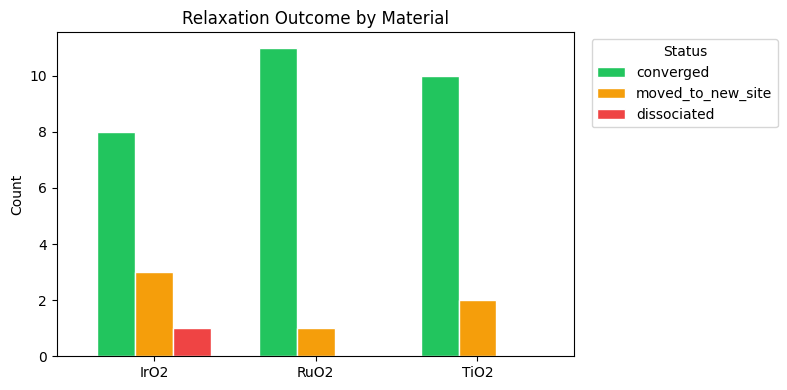

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
status_counts = relaxation_df.groupby(["material", "status"]).size().unstack(fill_value=0)

colors = {
    "converged": "#22c55e",
    "moved_to_new_site": "#f59e0b",
    "dissociated": "#ef4444",
    "desorbed": "#6366f1",
    "needs_review": "#9ca3af",
}
ordered_statuses = [s for s in colors if s in status_counts.columns]
status_counts[ordered_statuses].plot.bar(
    ax=ax, color=[colors[s] for s in ordered_statuses], edgecolor="white", width=0.7
)
ax.set_ylabel("Count")
ax.set_title("Relaxation Outcome by Material")
ax.set_xlabel("")
ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "relaxation_status.png"), dpi=150)
plt.show()

In [29]:
# Before/after comparison for a converged IrO2+OOH structure
example_config = ("IrO2", "OOH", "cus", 0.0)

if example_config in relaxation_results:
    init_atoms, _ = configs[example_config]
    relax_atoms = atomic_data_to_ase(relaxation_results[example_config])
    display_widgets_row([
        ("Before relaxation", init_atoms),
        ("After relaxation", relax_atoms),
    ], width="400px", height="350px", show_cell=False)
else:
    print("Skipping before/after (key not in results).")

### Surface displacement upon adsorption

A good OER catalyst ideally shows **minimal rearrangement of its surface atoms** when an intermediate binds.  Large atomic displacements suggest the surface may reconstruct under operating conditions, complicating practical use and potentially degrading long-term stability.

Below we colour-map the displacement of each slab atom from its initial position (blue = small, red = large).

In [30]:
# Compute surface displacement for converged structures
disp_data = {}
for config, result in relaxation_results.items():
    mat, ads, site, tilt = config
    row = relaxation_df.loc[
        (relaxation_df["material"] == mat)
        & (relaxation_df["adsorbate"] == ads)
        & (relaxation_df["site"] == site)
        & (relaxation_df["tilt"] == int(tilt))
    ]
    init_atoms, _ = configs[config]
    relax_atoms = atomic_data_to_ase(result)
    n_slab = len(slabs_opt[mat])
    disp = compute_surface_displacement(init_atoms, relax_atoms, n_slab)
    disp_data[config] = disp

# Pick one representative config per material (largest max displacement)
representatives = {}
for config, disp in disp_data.items():
    mat = config[0]
    if mat not in representatives or disp.max() > disp_data[representatives[mat]].max():
        representatives[mat] = config

# Global normalisation so colours are comparable across materials
all_disp = np.concatenate([disp_data[c] for c in representatives.values()])
d_max = all_disp.max() if all_disp.max() > 1e-6 else 1.0

# Build OVITO widgets with displacement colour-mapping
widget_items = []
widget_colors = []
for name in RUTILE_PARAMS:
    config = (name, "OH", "cus", 0)
    mat, ads, site, tilt = config
    row = relaxation_df.loc[
        (relaxation_df["material"] == mat)
        & (relaxation_df["adsorbate"] == ads)
        & (relaxation_df["site"] == site)
        & (relaxation_df["tilt"] == int(tilt))
    ]
    relax_atoms = atomic_data_to_ase(relaxation_results[config])
    n_slab = len(slabs_opt[name])
    disp = disp_data[config]

    # Slab atoms: grey (low disp) -> red (high disp)
    disp_norm = np.clip(disp / d_max, 0.0, 1.0)
    grey = np.array([0.70, 0.70, 0.70])
    red = np.array([0.85, 0.15, 0.15])
    slab_rgb = grey + disp_norm[:, None] * (red - grey)

    # Adsorbate atoms: light grey
    n_ads = len(relax_atoms) - n_slab
    ads_rgb = np.full((n_ads, 3), 0.75)

    colors = np.vstack([slab_rgb, ads_rgb])
    label = f"{name}+{ads} ({site}, tilt={int(tilt)}\u00b0)"
    widget_items.append((label, relax_atoms))
    widget_colors.append(colors)

display_widgets_row(
    widget_items, width="350px", height="350px",
    particle_colors_list=widget_colors, show_cell=False,
)

# Print displacement summary
for mat_name in RUTILE_PARAMS:
    if mat_name not in representatives:
        continue
    config = representatives[mat_name]
    disp = disp_data[config]
    print(f"{mat_name}: mean={disp.mean():.3f} \u00c5, max={disp.max():.3f} \u00c5"
          f" (config: {config[1]} {config[2]} tilt={int(config[3])}\u00b0)")
# Displacement colour scale bar (matches grey->red widget colouring)
cmap_disp = LinearSegmentedColormap.from_list(
    "disp", [(0.70, 0.70, 0.70), (0.85, 0.15, 0.15)]
)
fig_cb, ax_cb = plt.subplots(figsize=(8, 0.4))
norm = plt.Normalize(0, d_max)
fig_cb.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap_disp),
    cax=ax_cb, orientation="horizontal",
    label="Slab atom displacement (\u00c5)",
)
fig_cb.tight_layout()
plt.show()

IrO2: mean=0.007 Å, max=0.486 Å (config: O bridge tilt=30°)
RuO2: mean=0.012 Å, max=0.620 Å (config: O bridge tilt=30°)
TiO2: mean=0.010 Å, max=0.891 Å (config: O cus tilt=30°)


NameError: name 'LinearSegmentedColormap' is not defined

NameError: name 'cmap_disp' is not defined

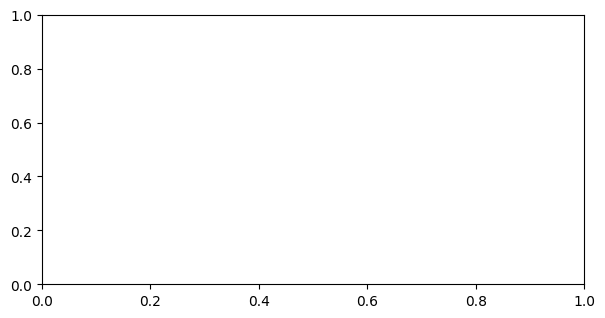

In [31]:
# Max displacement per (material, adsorbate) combination
grid_rows = []
for config, disp in disp_data.items():
    mat, ads, site, tilt = config
    grid_rows.append({"Material": mat, "Adsorbate": ads,
                      "Max disp (\u00c5)": float(disp.max())})

grid_df = pd.DataFrame(grid_rows)
pivot = grid_df.groupby(["Material", "Adsorbate"])["Max disp (\u00c5)"].max().unstack()

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(pivot.values, cmap=cmap_disp, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}",
                    ha="center", va="center", fontsize=10,
                    color="white" if val > pivot.values[~np.isnan(pivot.values)].mean() else "black")

ax.set_title("Max Slab Atom Displacement (\u00c5) by Material \u00d7 Adsorbate", fontsize=12)
fig.colorbar(im, ax=ax, label="Max displacement (\u00c5)", shrink=0.8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "displacement_grid.png"), dpi=150)
plt.show()

---
## 9. Adsorption Energies

With clean slab and gas-phase reference energies in hand, we compute the adsorption energy for every converged structure:

$$E_{\text{ads}} = E(\text{slab+adsorbate}) - E(\text{clean slab}) - E(\text{gas-phase molecule})$$

A **negative** value indicates exothermic (favourable) binding.  We then rank configurations within each material–adsorbate block by $E_{\text{ads}}$.

In [38]:
# Compute adsorption energies for all converged/moved structures
e_ads_rows = []
# Compute surface displacement for converged IrO2 structures
for config, result in relaxation_results.items():
    mat, ads, site, tilt = config
    row = relaxation_df.loc[(relaxation_df["material"] == mat)
                                        & (relaxation_df["adsorbate"] == ads)
                                        & (relaxation_df["site"] == site)
                                        & (relaxation_df["tilt"] == int(tilt))]
    #if row["status"].item() not in ("converged", "moved_to_new_site"):
    #    continue
    init_atoms, _ = configs[config]
    relax_atoms = atomic_data_to_ase(result)
    slab_n_atoms = len(slabs_opt[mat])
    disp = compute_surface_displacement(init_atoms, relax_atoms, slab_n_atoms)
    if row["status"].item() in ("desorbed", "needs_review"):
        continue
        
    # E_ads = E(slab+adsorbate) - E(clean slab) - E(gas-phase molecule)
    e_ads = float(row["energy"].item()) - slabs_opt_results[mat].energy - adsorbates_opt_results[ads].energy
    e_ads_rows.append({
        "Material": mat, 
        "Adsorbate": ads, 
        "Site": site,
        "Tilt (°)": tilt,
        "E_ads (eV)": round(e_ads, 4),
        "Status": row["status"].item()
    })

e_ads_df = pd.DataFrame(e_ads_rows)
display(e_ads_df)

,Material,Adsorbate,Site,Tilt (°),E_ads (eV),Status
0,IrO2,OH,cus,0.0,-3.6271,converged
1,IrO2,OH,cus,30.0,-3.6231,converged
2,IrO2,OH,bridge,0.0,-3.6253,moved_to_new_site
3,IrO2,OH,bridge,30.0,-2.6431,converged
4,IrO2,O,cus,0.0,-4.4547,converged
5,IrO2,O,cus,30.0,-4.4537,converged
6,IrO2,O,bridge,0.0,-3.6461,converged
7,IrO2,O,bridge,30.0,-3.6472,converged
8,IrO2,OOH,cus,0.0,-2.8785,dissociated
9,IrO2,OOH,cus,30.0,-2.8202,converged


<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/var/folders/v2/hkl3fwp903j2pgkyq0nlpdmh0000gn/T/ipykernel_54054/1069398567.py:27: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(im, ax=ax, label="$E_{\mathrm{ads}}$ (eV)", shrink=0.8)


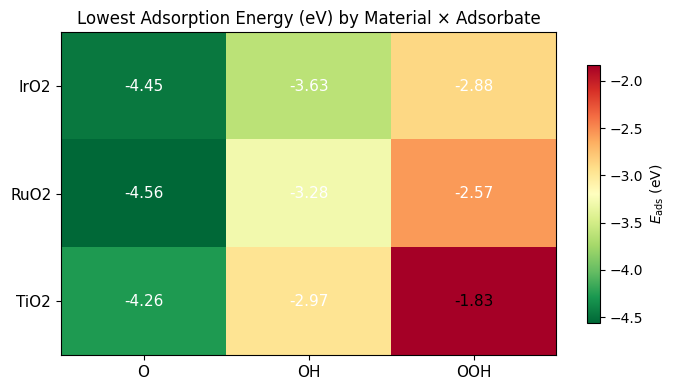

In [39]:
# Heatmap: lowest adsorption energy per (Material, Adsorbate)
pivot = e_ads_df.groupby(["Material", "Adsorbate"])["E_ads (eV)"].min().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

# Annotate cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                color="white" if abs(val) > 2 else "black",
            )

ax.set_title("Lowest Adsorption Energy (eV) by Material × Adsorbate", fontsize=12)
fig.colorbar(im, ax=ax, label="$E_{\mathrm{ads}}$ (eV)", shrink=0.8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "eads_heatmap.png"), dpi=150)
plt.show()

In [40]:
# Nearest metal-adsorbate distances for converged structures
bond_rows = []
for row in classification_rows:
    if row["status"] == "desorbed":
        continue
    bond_rows.append(
        {
            "Material": row["material"],
            "Adsorbate": row["adsorbate"],
            "Site": row["site"],
            "Tilt": row["tilt"],
            "Metal-O dist (Å)": f"{row['nearest_metal_dist']:.3f}",
            "Height (Å)": f"{row['adsorbate_height']:.3f}",
            "Status": row["status"],
        }
    )
display(pd.DataFrame(bond_rows))

NameError: name 'classification_rows' is not defined

---
## 10. Screening Results & Material Ranking

### 3-D Adsorption-Energy Scatter

For each material, we take the **lowest** adsorption energy across all sites and orientations for each OER intermediate (OH$^*$, O$^*$, OOH$^*$).  The three energies define a point in 3-D adsorption-energy space.

> **Reference-state caveat.**  The adsorption energies computed above use gas-phase radical species (O, OH, OOH) as references — *not* the H$_2$O/H$_2$ reference of the **computational hydrogen electrode** (CHE) framework [Rossmeisl *et al.*, 2007].  In the standard CHE approach, the ideal OER catalyst has cumulative reaction free energies $\Delta G_{\text{OH}^*} = 1.23$, $\Delta G_{\text{O}^*} = 2.46$, $\Delta G_{\text{OOH}^*} = 3.69$ eV — including zero-point energy and entropy corrections relative to liquid water and gaseous H$_2$.  Our binding energies use a different reference state and omit thermal corrections, so they are **not directly comparable** to CHE free energies in absolute terms.

Nevertheless, the **Euclidean distance** in binding-energy space is a useful **relative ranking proxy**: materials closer to each other exhibit similar adsorption chemistry, and the *relative* ordering can guide which candidates merit more rigorous follow-up with proper CHE thermodynamics, explicit solvent, and experiment.

<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
/var/folders/v2/hkl3fwp903j2pgkyq0nlpdmh0000gn/T/ipykernel_54054/4203820584.py:64: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$E_{\mathrm{ads}}$(OH$^*$) (eV)", fontsize=10, labelpad=8)
/var/folders/v2/hkl3fwp903j2pgkyq0nlpdmh0000gn/T/ipykernel_54054/4203820584.py:65: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$E_{\mathrm{ads}}$(O$^*$) (eV)", fontsize=10, labelpad=8)
/var/folders/v2/hkl3fwp903j2pgkyq0nlpdmh0000gn/T/ipykernel_54054/4203820584.py:66: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel("$E_{\mathrm{ads}}$(OOH$^*$) (eV)", fontsize=10, labelpad=8)


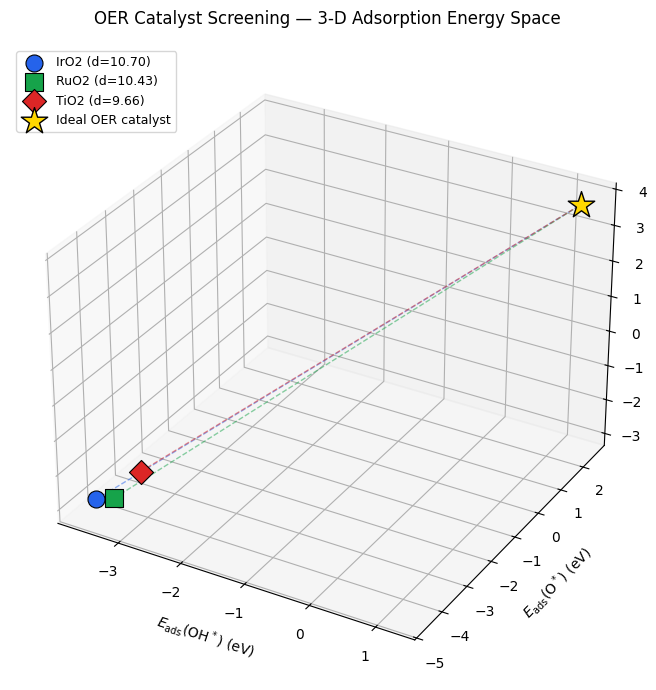

In [41]:
# Build best E_ads per (material, OER intermediate)
oer_intermediates = ["OH", "O", "OOH"]
# CHE ideal target (1.23, 2.46, 3.69 eV) — used here as a relative
# ranking reference, not as a direct thermodynamic comparison (see caveat above).
target = np.array([1 * EV_PER_OER_STEP, 2 * EV_PER_OER_STEP, 3 * EV_PER_OER_STEP])

mat_points = {}
for mat_name in RUTILE_PARAMS:
    point = []
    for ads in oer_intermediates:
        subset = e_ads_df[
            (e_ads_df["Material"] == mat_name) & (e_ads_df["Adsorbate"] == ads)
        ]
        if len(subset) > 0:
            point.append(subset["E_ads (eV)"].min())
        else:
            point.append(np.nan)
    mat_points[mat_name] = np.array(point)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

mat_colors = {"IrO2": "#2563eb", "RuO2": "#16a34a", "TiO2": "#dc2626"}
mat_markers = {"IrO2": "o", "RuO2": "s", "TiO2": "D"}

# Plot material points
for mat_name, pt in mat_points.items():
    if np.any(np.isnan(pt)):
        continue
    dist = np.linalg.norm(pt - target)
    ax.scatter(
        *pt,
        c=mat_colors[mat_name],
        marker=mat_markers[mat_name],
        s=150,
        edgecolors="k",
        linewidth=0.8,
        zorder=5,
        label=f"{mat_name} (d={dist:.2f})",
    )
    # Dashed line to target
    ax.plot(
        [pt[0], target[0]],
        [pt[1], target[1]],
        [pt[2], target[2]],
        "--",
        color=mat_colors[mat_name],
        alpha=0.5,
        lw=1,
    )

# Plot target point
ax.scatter(
    *target,
    c="gold",
    marker="*",
    s=400,
    edgecolors="k",
    linewidth=1,
    zorder=10,
    label="Ideal OER catalyst",
)

ax.set_xlabel("$E_{\mathrm{ads}}$(OH$^*$) (eV)", fontsize=10, labelpad=8)
ax.set_ylabel("$E_{\mathrm{ads}}$(O$^*$) (eV)", fontsize=10, labelpad=8)
ax.set_zlabel("$E_{\mathrm{ads}}$(OOH$^*$) (eV)", fontsize=10, labelpad=8)
ax.set_title(
    "OER Catalyst Screening — 3-D Adsorption Energy Space", fontsize=12, pad=15
)
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(
    os.path.join(OUTPUT_DIR, "oer_3d_scatter.png"), dpi=150, bbox_inches="tight"
)
plt.show()

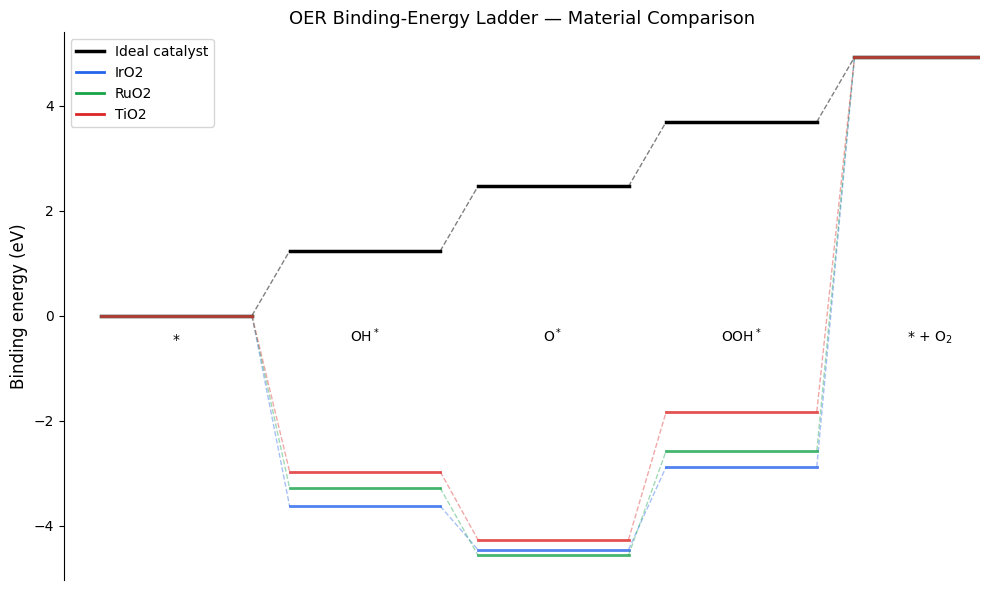

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ideal catalyst
ideal_steps = [0.0, 1.23, 2.46, 3.69, 4.92]
labels = ["$*$", "OH$^*$", "O$^*$", "OOH$^*$", "$*$ + O$_2$"]


def plot_energy_ladder(ax, steps_vals, color, label, lw=2, alpha=1.0):
    for i in range(len(steps_vals)):
        x0 = i * 1.5
        ax.plot(
            [x0, x0 + 1.2],
            [steps_vals[i], steps_vals[i]],
            color=color,
            lw=lw,
            alpha=alpha,
        )
        if i < len(steps_vals) - 1:
            ax.plot(
                [x0 + 1.2, (i + 1) * 1.5],
                [steps_vals[i], steps_vals[i + 1]],
                color=color,
                lw=1,
                alpha=alpha * 0.5,
                linestyle="--",
            )
    ax.plot([], [], color=color, lw=lw, label=label)


plot_energy_ladder(ax, ideal_steps, "black", "Ideal catalyst", lw=2.5)

# Material ladders from computed adsorption energies
for mat_name in RUTILE_PARAMS:
    mat_steps = [0.0]
    valid = True
    for ads in oer_intermediates:
        subset = e_ads_df[
            (e_ads_df["Material"] == mat_name) & (e_ads_df["Adsorbate"] == ads)
        ]
        if len(subset) > 0:
            mat_steps.append(subset["E_ads (eV)"].min())
        else:
            valid = False
            break
    if valid:
        # Final step: O2 release = 4.92 eV total
        mat_steps.append(4.92)
        plot_energy_ladder(
            ax, mat_steps, mat_colors[mat_name], mat_name, lw=2, alpha=0.8
        )

# Labels
for i, lbl in enumerate(labels):
    ax.text(i * 1.5 + 0.6, -0.5, lbl, ha="center", fontsize=10)

ax.set_ylabel("Binding energy (eV)", fontsize=12)
ax.set_title("OER Binding-Energy Ladder — Material Comparison", fontsize=13)
ax.legend(fontsize=10, loc="upper left")
ax.set_xlim(-0.3, 7)
ax.set_xticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "oer_material_comparison.png"), dpi=150)
plt.show()

In [34]:
# Rank materials by Euclidean distance to ideal OER target
ranking_rows = []
for mat_name, pt in mat_points.items():
    if np.any(np.isnan(pt)):
        ranking_rows.append(
            {
                "Material": mat_name,
                "Distance to ideal": np.nan,
                "E_ads(OH*)": np.nan,
                "E_ads(O*)": np.nan,
                "E_ads(OOH*)": np.nan,
            }
        )
        continue
    dist = float(np.linalg.norm(pt - target))
    ranking_rows.append(
        {
            "Material": mat_name,
            "E_ads(OH*) (eV)": round(pt[0], 3),
            "E_ads(O*) (eV)": round(pt[1], 3),
            "E_ads(OOH*) (eV)": round(pt[2], 3),
            "Distance to ideal": round(dist, 3),
        }
    )

ranking_df = pd.DataFrame(ranking_rows).sort_values("Distance to ideal")
display(ranking_df)

best = ranking_df.iloc[0]["Material"]
print(f"\nClosest to ideal OER catalyst: {best}")

,Material,E_ads(OH*) (eV),E_ads(O*) (eV),E_ads(OOH*) (eV),Distance to ideal
1,RuO2,-3.176,-3.699,1.349,7.926
0,IrO2,-3.211,-4.433,2.022,8.368
2,TiO2,1.001,13.131,3.975,10.677



Closest to ideal OER catalyst: RuO2


---
## Discussion

### Key observations

- **Which initial guesses relaxed to the same final motif?**  Multiple starting configurations (different sites, orientations) may converge to identical relaxed geometries — this is a sign that the potential energy surface has a clear minimum for that adsorbate on that surface.

- **Which surface holds OH$^*$ most stably?**  The adsorption energy heatmap shows which material binds each intermediate most strongly.  Strong OH$^*$ binding is a prerequisite for OER activity, but binding that is *too* strong leads to poisoning.

- **Does H$_2$O$^*$ stay molecular or dissociate?**  On stoichiometric IrO$_2$(110), strong dissociative water adsorption is well-documented in the literature.  Observing this in the relaxation is a useful validation of the MLIP model's qualitative accuracy.

- **How does OOH$^*$ behave?**  The peroxo intermediate is often the least stable of the three OER intermediates.  Its relaxed geometry (intact O–O bond, orientation relative to the surface) contains information about the feasibility of the O$_2$-release step.

- **Surface displacement.**  Materials that showed minimal surface rearrangement upon adsorbate binding are more likely to be practically stable catalysts.  Large displacements suggest the surface may reconstruct under OER conditions.


### Caveats

This notebook performs **vacuum-slab structural screening** — a useful first funnel, but not a definitive mechanistic study.  Important physics that is missing:

> **Note on accuracy.** The adsorption energies computed here use the MACE-MP-0 MLIP [1], not DFT. MACE-MP-0 captures structural trends and relative energetics well, but absolute free energies — and therefore quantitative overpotentials — should be validated against DFT or experiment before drawing catalytic conclusions [1, 4].

- **Explicit solvent and electrochemical potential**: water molecules at the electrode–electrolyte interface stabilise intermediates through hydrogen bonding and dielectric screening.
- **Zero-point energy (ZPE) and entropy corrections**: converting electronic adsorption energies to free energies requires vibrational contributions.
- **Coverage effects**: at operating potentials, the surface may be partially covered by multiple intermediates simultaneously.
- **MLIP accuracy**: MACE-MP-0 is a broadly capable foundation model, but its accuracy on surface-adsorption energetics for specific oxides should be validated against DFT references.

The strongest message for tutorial attendees: **batched MLIP relaxation is excellent for rapid structural screening and hypothesis pruning, but final catalyst claims still require richer physics and downstream validation.**

---
## 11. Extensions & Scaling

| Direction | What it adds |
|-----------|-------------|
| **Explicit solvent** | Solvation stabilises OH$^*$ and OOH$^*$ differently; improves free-energy accuracy |
| **ZPE & entropy corrections** | Converts $E_{\text{ads}}$ to $\Delta G$; essential for overpotential estimates |
| **Alloy surfaces** | Ir$_x$Ru$_{1-x}$O$_2$ and doped TiO$_2$ explore cost–activity trade-offs |
| **Higher-coverage screening** | Co-adsorbed intermediates (e.g. OH$^*$ + O$^*$) at realistic potentials |
| **Agentic AI loop** | An LLM agent picks the next surface/adsorbate configuration based on prior results, closing the active-learning loop |
| **DFT validation** | Spot-check the most promising MLIP results with hybrid-functional DFT |

## Summary

1. **Batching enables many structural hypotheses.** We screened 30+ slab-adsorbate configurations across three rutile oxides in a single interactive session — a throughput that would be impractical with serial DFT calculations.

2. **Quality control is essential.** Not every relaxed structure is scientifically useful.  Classification into converged / migrated / dissociated / desorbed categories separates reliable data from noise.

3. **Vacuum relaxation is the first funnel, not the last.** The adsorption-energy ranking and 3-D scatter plot provide a rapid first screen, but final catalyst claims require explicit solvent, free-energy corrections, and experimental validation.

### Discussion Prompts

1. Did batching help primarily because we had **many materials**, or because we had **many structural hypotheses** per material?
2. Is the lowest-energy relaxed structure automatically the best catalyst?
3. What extra physics is missing from a vacuum slab relaxation, and which missing piece matters most for OER?
4. When should you escalate from MLIP screening to DFT, explicit solvent, or experiment?
5. How might an **agentic AI** system decide which configuration to try next?

## References

1. Batatia, I. *et al.* "MACE: Higher Order Equivariant Message Passing Neural Networks for Fast and Accurate Force Fields." *NeurIPS* (2022). — MACE-MP-0 foundation model covering 89 elements trained on 1.6 M Materials Project structures.
2. Rossmeisl, J., Qu, Z.-W., Zhu, H., Kroes, G.-J. & Nørskov, J. K. "Electrolysis of water on oxide surfaces." *J. Electroanal. Chem.* **607**, 83–89 (2007). — OER thermodynamic framework with four PCET steps and 1.23 eV ideal step energy.
3. Ping, Y., Nielsen, R. J. & Goddard, W. A. "The Reaction Mechanism with Free Energy Barriers at Constant Potentials for the Oxygen Evolution Reaction at the IrO$_2$ (110) Surface." *J. Am. Chem. Soc.* **139**, 149–155 (2017). — IrO$_2$(110) as OER reference; strong dissociative H$_2$O adsorption at the CUS site.
4. Dickens, C. F., Kirk, C. & Nørskov, J. K. "Insights into the Electrochemical Oxygen Evolution Reaction with ab Initio Calculations and Microkinetic Modeling: Beyond the Limiting Potential Volcano." *J. Phys. Chem. C* **123**, 18960–18977 (2019). — Comparative OER study on TiO$_2$, RuO$_2$, and IrO$_2$ (110) surfaces.
5. Stukowski, A. "Visualization and analysis of atomistic simulation data with OVITO — the Open Visualization Tool." *Model. Simul. Mater. Sci. Eng.* **18**, 015012 (2010).
6. U.S. Geological Survey. "2022 Final List of Critical Minerals." *Federal Register* **87**, 10381 (2022). — Iridium among 60 critical minerals.
7. ENEOS Holdings, Matlantis, and NVIDIA. Collaboration on GPU-accelerated atomistic simulation for catalyst discovery.
8. Atkins, P. W. & de Paula, J. *Atkins' Physical Chemistry*, 10th ed. Oxford University Press (2014). — Standard electrode potentials and the thermodynamics of water splitting.
9. Carmo, M., Fritz, D. L., Mergel, J. & Stolten, D. "A comprehensive review on PEM water electrolysis." *Int. J. Hydrogen Energy* **38**, 4901–4934 (2013). — Review of PEM electrolyser technology, overpotential sources, and catalyst requirements.
10. Nørskov, J. K., Rossmeisl, J., Logadottir, A. *et al.* "Origin of the Overpotential for Oxygen Reduction at a Fuel-Cell Cathode." *J. Phys. Chem. B* **108**, 17886–17892 (2004). — Computational hydrogen electrode (CHE) framework for electrocatalysis.
11. Man, I. C. *et al.* "Universality in Oxygen Evolution Electrocatalysis on Oxide Surfaces." *ChemCatChem* **3**, 1159–1165 (2011). — OER scaling relations: $\Delta G_{\mathrm{OOH}^*} \approx \Delta G_{\mathrm{OH}^*} + 3.2$ eV across oxide families.
12. Nishimura, T. *et al.* "Water Dissociation on IrO$_2$(110): a Combined Experimental and Theoretical Study." *J. Phys. Chem. C* **127**, 9751–9759 (2023). — Dissociative water adsorption at the CUS site on IrO$_2$(110).